In [195]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import re

from sklearn.model_selection import train_test_split

In [196]:
#lese inn datasettet
df = pd.read_csv("persona_survey.csv")
print(df.head())

  persona_id            name  type          occupation occupation_category  \
0      f0000    Isaac Newton  real           physicist  science & medicine   
1      f0001    Donald Trump  real          politician     politics & rule   
2      f0002    Genghis Khan  real  military personnel            military   
3      f0003       Cleopatra  real          politician     politics & rule   
4      f0004  Mahatma Gandhi  real     social activist               other   

  gender    born    died                    born_city    born_country  ...  \
0      M  1643.0  1726.0  Woolsthorpe-by-Colsterworth  United Kingdom  ...   
1      M  1946.0     NaN                       Queens   United States  ...   
2      M  1162.0  1227.0            Khentii Mountains        Mongolia  ...   
3      F   -69.0   -30.0                   Alexandria           Egypt  ...   
4      M  1869.0  1948.0                    Porbandar           India  ...   

                         personal.last_meal  personal.favorite

In [197]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 74 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   persona_id                                      10000 non-null  str    
 1   name                                            10000 non-null  str    
 2   type                                            10000 non-null  str    
 3   occupation                                      9964 non-null   str    
 4   occupation_category                             9964 non-null   str    
 5   gender                                          9965 non-null   str    
 6   born                                            9965 non-null   float64
 7   died                                            7770 non-null   float64
 8   born_city                                       9499 non-null   str    
 9   born_country                                    967

,born,died,fame_rank,sections_ok,big_five.EXT1,big_five.EXT2,big_five.EXT5,big_five.EXT10,big_five.EST1,big_five.EST2,...,personal.weight_kg,personal.life_satisfaction,moral_exchange_rates.cats_per_human,moral_exchange_rates.dogs_per_human,moral_exchange_rates.chickens_per_human,moral_exchange_rates.cows_per_human,moral_exchange_rates.trees_per_human,moral_exchange_rates.cats_per_dog,moral_exchange_rates.dogs_per_cow,moral_exchange_rates.chickens_per_cow
count,9965.000000,7770.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,9992.000000,9992.000000,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04
mean,1441.929955,1499.814286,4100.500000,5.094200,3.238800,2.899800,3.328200,3.266700,2.553200,3.722200,...,79.957966,8.477682,1.808384e+07,1.771819e+07,2.007507e+07,1.769203e+07,8.699437e+07,9.001102e+05,1.100321e+06,1.200815e+06
std,986.401409,791.620188,2743.006682,0.293828,1.280367,1.296275,1.248215,1.165464,0.837401,0.877442,...,90.883438,0.995889,1.316255e+08,1.309195e+08,1.316560e+08,1.312055e+08,2.598679e+08,2.998799e+07,3.314965e+07,3.462194e+07
min,-10000.000000,-3255.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000e-09,1.000000e-09,1.000000e-12,1.000000e-10,1.000000e-12,1.000000e-06,1.000000e-02,1.000000e-04
25%,1439.000000,1405.000000,1500.750000,5.000000,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,...,70.000000,8.000000,5.000000e+01,2.000000e+01,5.000000e+02,1.000000e+01,1.000000e+03,2.000000e+00,2.000000e+00,1.000000e+01
50%,1858.000000,1874.000000,4000.500000,5.000000,3.000000,3.000000,4.000000,4.000000,2.000000,4.000000,...,75.000000,9.000000,1.000000e+02,5.000000e+01,1.000000e+03,1.000000e+02,1.000000e+06,2.000000e+00,5.000000e+00,5.000000e+01
75%,1926.000000,1971.000000,6500.250000,5.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,...,82.000000,9.000000,1.000000e+06,5.000000e+05,1.000000e+06,1.000000e+05,1.000000e+07,2.500000e+00,5.000000e+00,1.000000e+02
max,10190.000000,3018.000000,9000.000000,6.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,2000.000000,10.000000,1.000000e+09,1.000000e+09,1.000000e+09,1.000000e+09,1.000000e+09,1.000000e+09,1.000000e+09,1.000000e+09


# Datavalidering

In [198]:
manglende = df.isna().sum()
manglende = manglende[manglende > 0].sort_values(ascending=False) 
manglende


died                                    2230
born_city                                501
born_country                             324
personal.favorite_person                  47
occupation                                36
occupation_category                       36
born                                      35
gender                                    35
personal.favorite_painting                25
personal.favorite_book                    24
values.child_quality_most_important       15
values.dictator_give_pct                  15
values.friend_crime_testify               15
values.p_living_in_simulation             15
values.p_god_exists                       15
values.free_will                          15
values.wants_to_live_forever              15
personal.favorite_animal                  15
values.random_people_per_me               15
personal.last_meal                        12
personal.favorite_thing_about_bergen       9
personal.favorite_data_science_fact        9
personal.w

- Undersøker om de manglende radene i del 2 born og occupation_category overlapper


In [199]:
manglende_occ_cat = df["occupation_category"].isna()
manglende_born = df["born"].isna()
print('Mangler occupation_category:', manglende_occ_cat.sum())
print('Mangler born:', manglende_born.sum())
print('Mangler begge:', (manglende_occ_cat & manglende_born).sum())


Mangler occupation_category: 36
Mangler born: 35
Mangler begge: 35


- Fjerner tomme data
    - Fjerner alle tomme data i occupation_category fordi det overlapper fullt med de tomme dataene i born

In [200]:
df_renset = df.dropna(subset=["occupation_category"])

In [201]:
manglende_occ_cat = df_renset["occupation_category"].isna()
manglende_born = df_renset["born"].isna()
print('Mangler occupation_category:', manglende_occ_cat.sum())
print('Mangler born:', manglende_born.sum())
print('Mangler begge:', (manglende_occ_cat & manglende_born).sum())

Mangler occupation_category: 0
Mangler born: 0
Mangler begge: 0


# Trening og Testsplitting
- Å bruke stratify på occupation_category gjør at dataene bli gjevnt fordelt i trening, validering og test dataene

In [202]:
train, temp, = train_test_split(df_renset, test_size=0.3, random_state=42, stratify=df_renset["occupation_category"])
val, test, = train_test_split(temp, test_size=0.5, random_state=42, stratify=temp["occupation_category"])

# Utforskende analyser

## Big 5 
Beregning av big 5 personligetspoeng

In [203]:
def reverse(x):
    return 6 - x

# Legger sammen 
def legg_til_big_five(d):
    d = d.copy()
    d['EXT_score'] = d['big_five.EXT1'] + reverse(d['big_five.EXT2']) + d['big_five.EXT5'] + reverse(d['big_five.EXT10'])
    d['EST_score'] = d['big_five.EST1'] + reverse(d['big_five.EST2']) + d['big_five.EST3'] + d['big_five.EST10']
    d['AGR_score'] = reverse(d['big_five.AGR1']) + d['big_five.AGR2'] + d['big_five.AGR4'] + reverse(d['big_five.AGR5'])
    d['CSN_score'] = d['big_five.CSN1'] + reverse(d['big_five.CSN2']) + d['big_five.CSN5'] + reverse(d['big_five.CSN8'])
    d['OPN_score'] = reverse(d['big_five.OPN2']) + d['big_five.OPN3'] + reverse(d['big_five.OPN6']) + d['big_five.OPN9']
    return d

train = legg_til_big_five(train)
val   = legg_til_big_five(val)
test  = legg_til_big_five(test)

## politiske meninger
Beregning av politiske meninger

In [204]:
train['political_compass.econ_redistribute_wealth'].unique()

<StringArray>
['agree', 'disagree', 'strongly agree', 'strongly disagree']
Length: 4, dtype: str

In [205]:
likert_map = {
    'strongly disagree': -2,
    'disagree': -1,
    'agree': 1,
    'strongly agree': 2
}

In [206]:
def legg_til_politisk_kompass(d):
    d = d.copy()
    
    econ_venstre = [
        'political_compass.econ_redistribute_wealth',
        'political_compass.econ_public_services',
        'political_compass.econ_tax_the_wealthy'
    ]
    econ_høyre = [
        'political_compass.econ_free_markets',
        'political_compass.econ_personal_responsibility',
        'political_compass.econ_welfare_dependency'
    ]
    soc_libertær = [
        'political_compass.soc_immigration_benefits',
        'political_compass.soc_legalize_drugs',
        'political_compass.soc_embrace_changing_norms'
    ]
    soc_autoritær = [
        'political_compass.soc_strong_leader',
        'political_compass.soc_harsh_punishment',
        'political_compass.soc_traditional_values_laws'
    ]
    
    venstre_sum = d[econ_venstre].apply(lambda col: col.map(likert_map)).sum(axis=1)
    høyre_sum = d[econ_høyre].apply(lambda col: col.map(likert_map)).sum(axis=1)
    d['pc_econ'] = venstre_sum - høyre_sum  
     # positiv = venstre, negativ = høyre
    
    lib_sum = d[soc_libertær].apply(lambda col: col.map(likert_map)).sum(axis=1)
    aut_sum = d[soc_autoritær].apply(lambda col: col.map(likert_map)).sum(axis=1)
    d['pc_soc'] = lib_sum - aut_sum          
    # positiv = libertær, negativ = autoritær
    
    return d

train = legg_til_politisk_kompass(train)
val   = legg_til_politisk_kompass(val)
test  = legg_til_politisk_kompass(test)

### Bruker de sammenslåtte dataene 

#### Big 5 mot jobbtyper

- Sjekker ekstoverthet utifra typen jobb

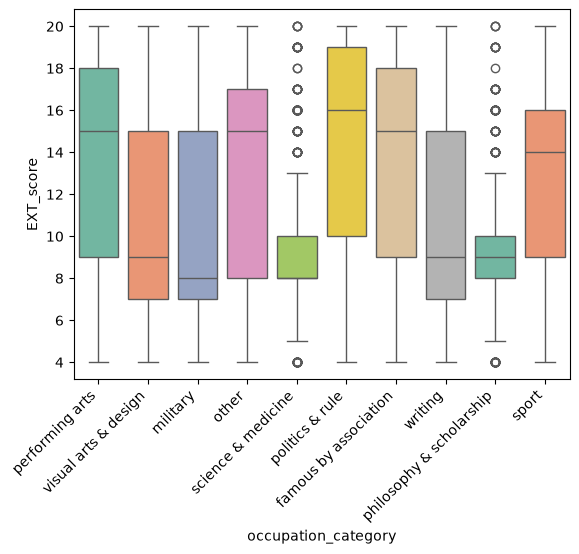

In [207]:
sns.boxplot(data=train, x='occupation_category', y='EXT_score', hue='occupation_category', palette='Set2', legend=False)
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

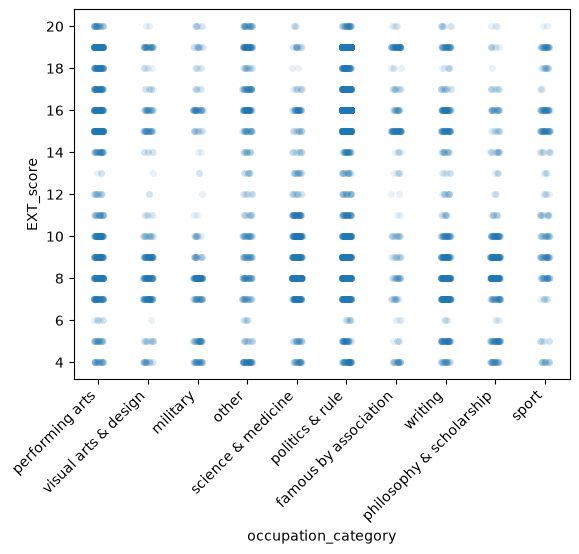

In [208]:
sns.stripplot(data=train, x='occupation_category', y='EXT_score', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

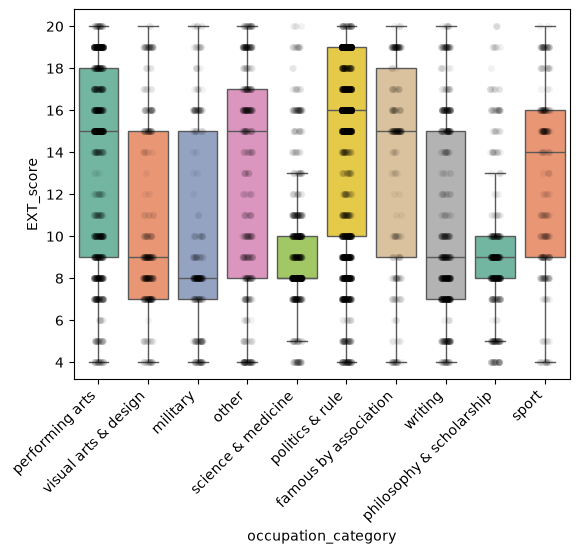

In [209]:
sns.boxplot(data=train, x='occupation_category', y='EXT_score', showfliers=False, hue='occupation_category', palette='Set2', legend=False)
sns.stripplot(data=train, x='occupation_category', y='EXT_score', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Grafene viser at modellen lener seg på stereotyper av jobber, den tror for eksempel politics og rule og performing arts er mest ekstrovert. Den mener også at science og medicine og philosophy og scolarship er minst ekstrovert

- Sjekker nevrotisisme utifra jobbtype

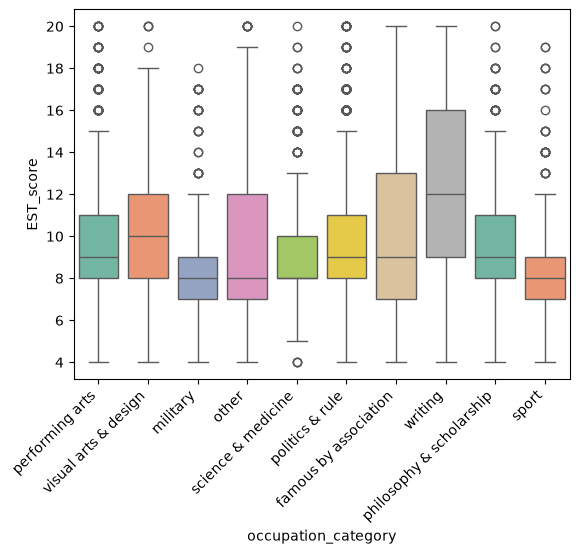

In [210]:
sns.boxplot(data=train, x='occupation_category', y='EST_score', hue='occupation_category', palette='Set2', legend=False)
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

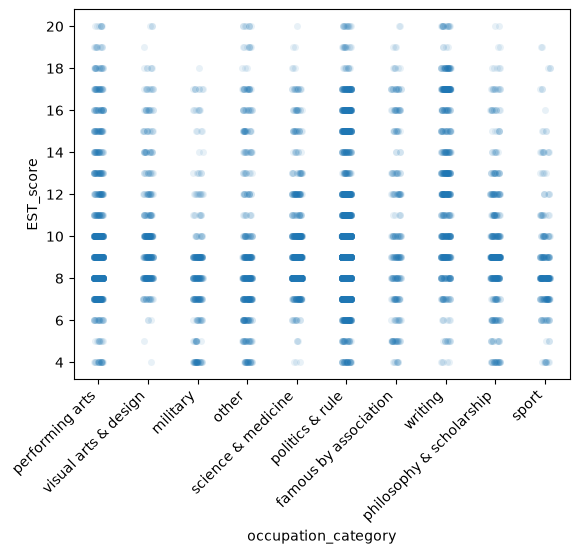

In [211]:
sns.stripplot(data=train, x='occupation_category', y='EST_score', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

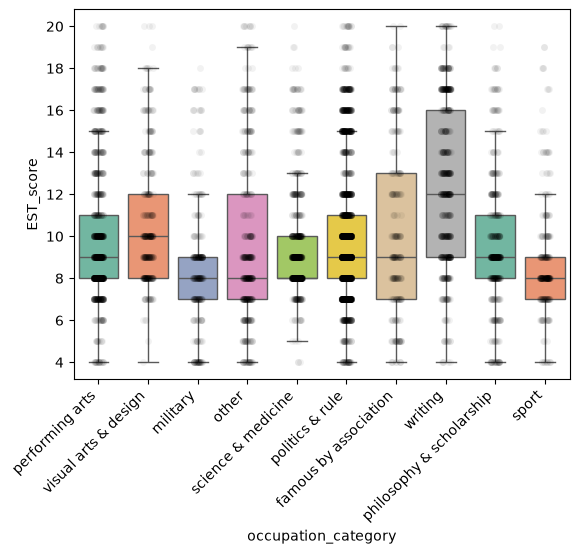

In [212]:
sns.boxplot(data=train, x='occupation_category', y='EST_score', showfliers=False, hue='occupation_category', palette='Set2', legend=False)
sns.stripplot(data=train, x='occupation_category', y='EST_score', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her lener modellen igjen på stereotyper der writing er den høyeste kategorien. Her er det military og sport som scorer lavest, dette mener jeg lener igjen på stereotypene til den følelsesløse soldaten eller en typisk sportspiller en "jock". Mer generelt så ser jeg at modellen er litt lent mot en lavere score 

- Sjekker omgjengelighet utifra jobbtype

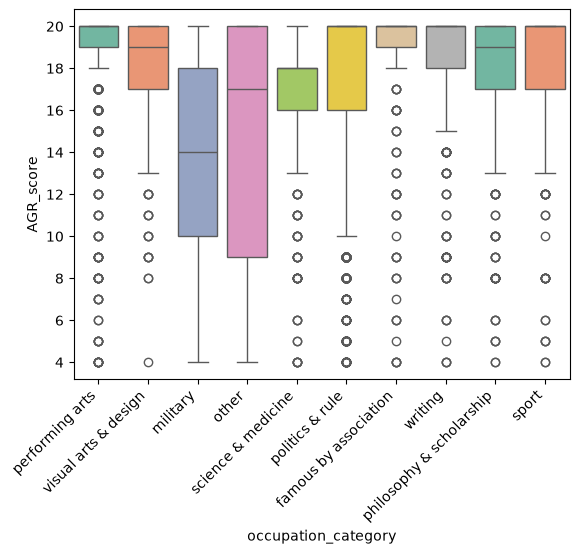

In [213]:
sns.boxplot(data=train, x='occupation_category', y='AGR_score', hue='occupation_category', palette='Set2', legend=False)
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

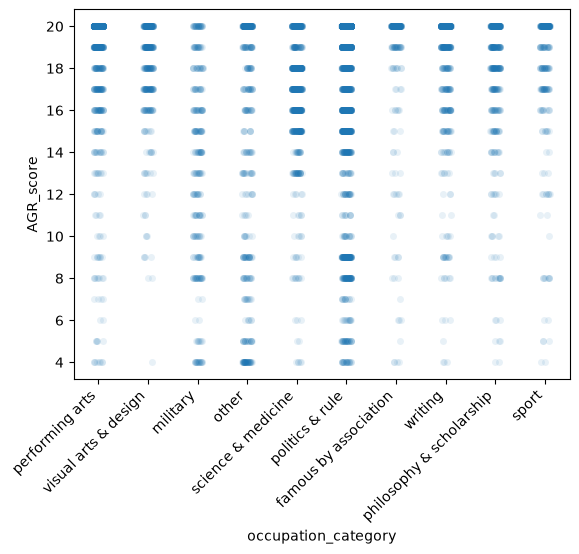

In [214]:
sns.stripplot(data=train, x='occupation_category', y='AGR_score', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

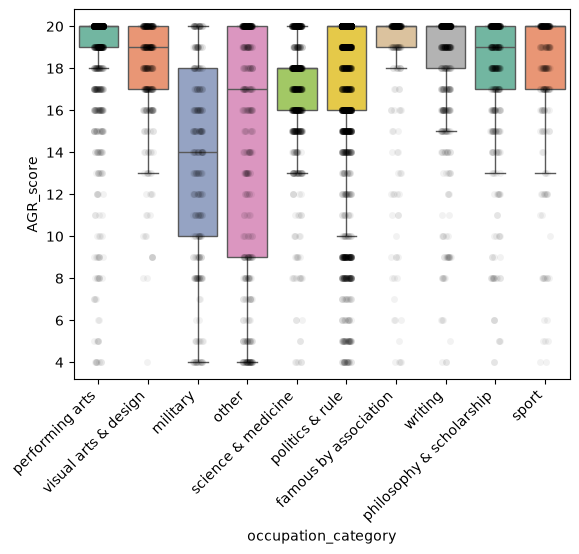

In [215]:
sns.boxplot(data=train, x='occupation_category', y='AGR_score', showfliers=False, hue='occupation_category', palette='Set2', legend=False)
sns.stripplot(data=train, x='occupation_category', y='AGR_score', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her er det et klart skifte, de fleste yrkene lener seg mot en veldig høy score i omgjengeliget. Det er en ganske stor spredning i military og other med noen som har veldig lav score, men generelt har alle en høy score.

- Sjekker planmessighet utifra jobbtype

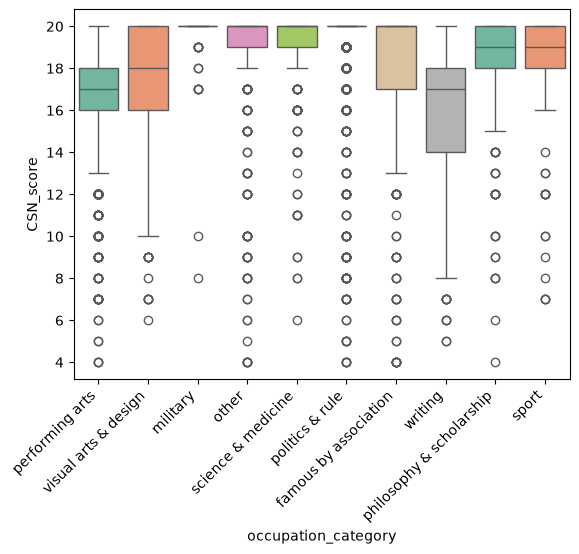

In [216]:
sns.boxplot(data=train, x='occupation_category', y='CSN_score', hue='occupation_category', palette='Set2', legend=False)
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

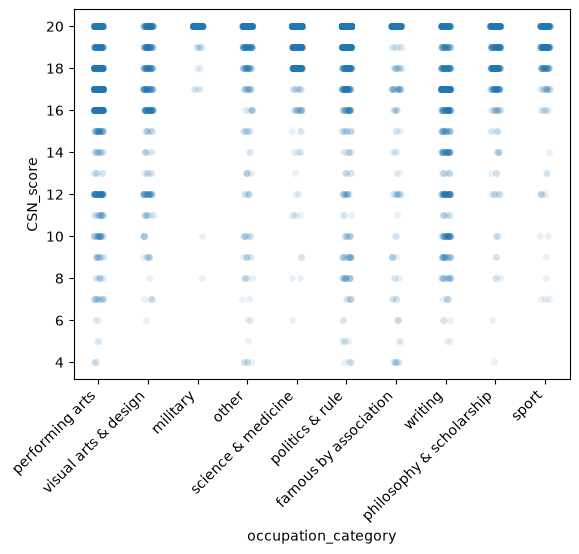

In [217]:
sns.stripplot(data=train, x='occupation_category', y='CSN_score', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

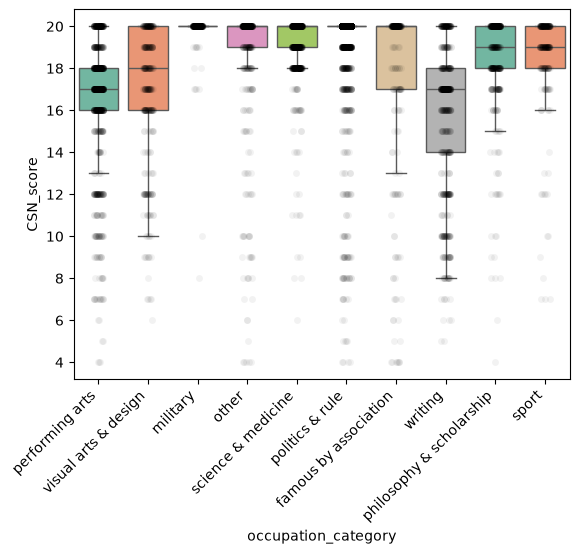

In [218]:
sns.boxplot(data=train, x='occupation_category', y='CSN_score', showfliers=False, hue='occupation_category', palette='Set2', legend=False)
sns.stripplot(data=train, x='occupation_category', y='CSN_score', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her lener modellen også en veldig høy score i planmessighet, men den bruker noen stereotyper, millitary har nesten bare toppscore og politikk og rule har også en veldig høy score. Writing har litt lavere score men der også er medianen på rundt 17 som er veldig høyt.

- Sjekker åpenhet mot jobbtype

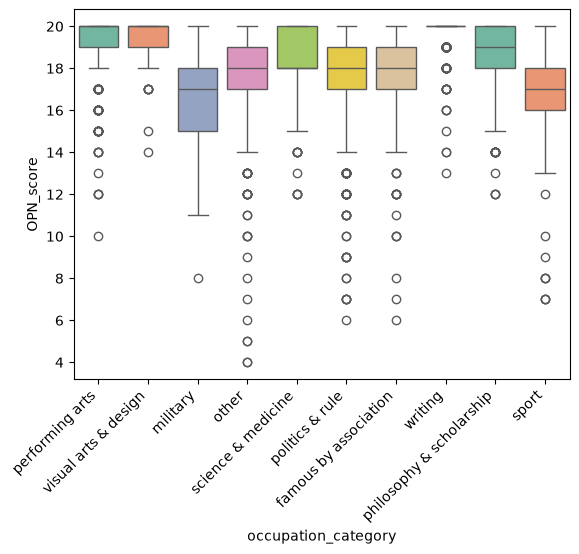

In [219]:
sns.boxplot(data=train, x='occupation_category', y='OPN_score', hue='occupation_category', palette='Set2', legend=False)
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

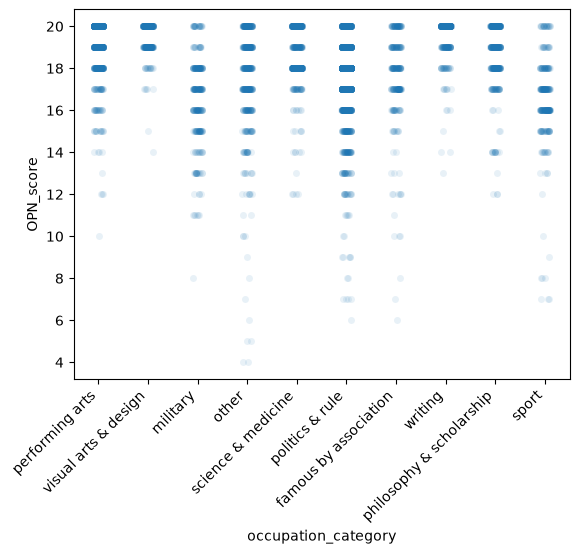

In [220]:
sns.stripplot(data=train, x='occupation_category', y='OPN_score', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

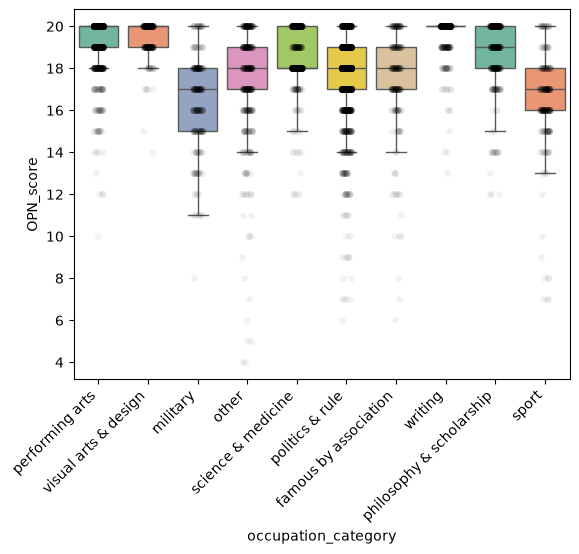

In [221]:
sns.boxplot(data=train, x='occupation_category', y='OPN_score', showfliers=False, hue='occupation_category', palette='Set2', legend=False)
sns.stripplot(data=train, x='occupation_category', y='OPN_score', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her er det også generelt høy score. Witing er mest åpen som igjen lener på en stereotyper, og millitary er litt mer tilbakeholden enn de andre men har fremdeles generelt en veldig høy score.

#### Politisk retning mot jobbtyper

- politisk økonomisk retning utifra jobbtyper

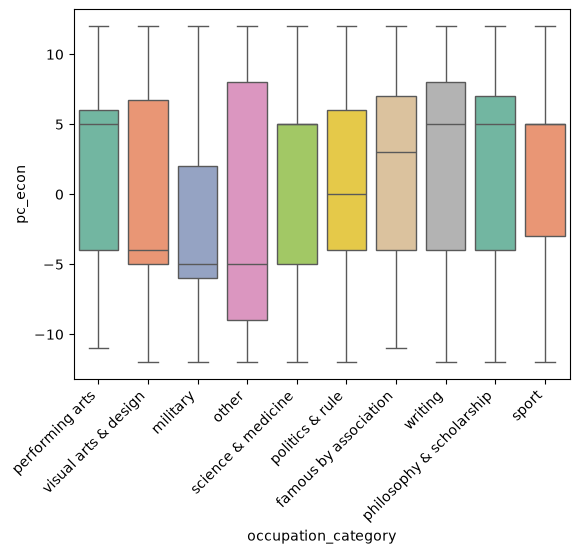

In [222]:
sns.boxplot(data=train, x='occupation_category', y='pc_econ', hue='occupation_category', palette='Set2', legend=False)
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

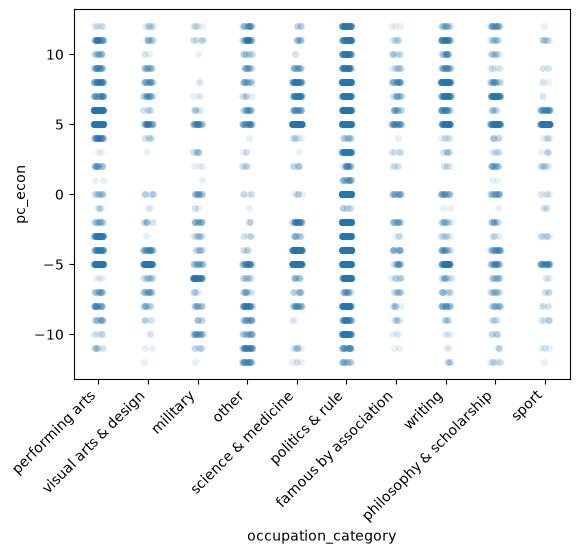

In [223]:
sns.stripplot(data=train, x='occupation_category', y='pc_econ', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

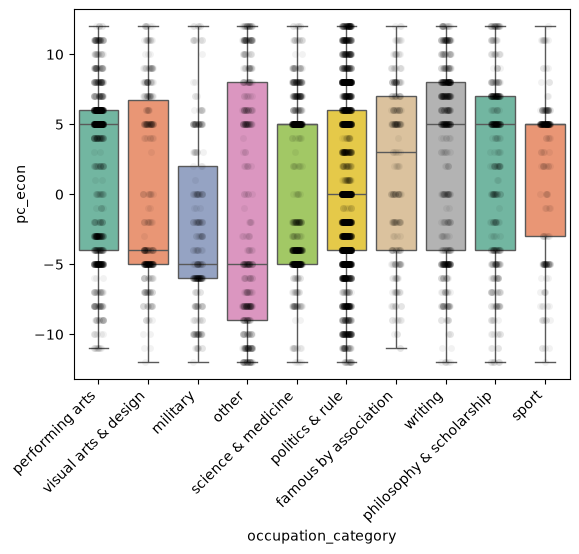

In [224]:
sns.boxplot(data=train, x='occupation_category', y='pc_econ', showfliers=False, hue='occupation_category', palette='Set2', legend=False)
sns.stripplot(data=train, x='occupation_category', y='pc_econ', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her er resultatene mer spredt, noe som tyder på at modellen ikke har like sterke antagelser på hvor hver person lener. Den har fremdeles noen stereotyper her, for eksempel at military lener mer mot høyre og at writing, performing arts og philosophy og scolarship lener mer mot venstre.

- politisk retning mot jobbtype

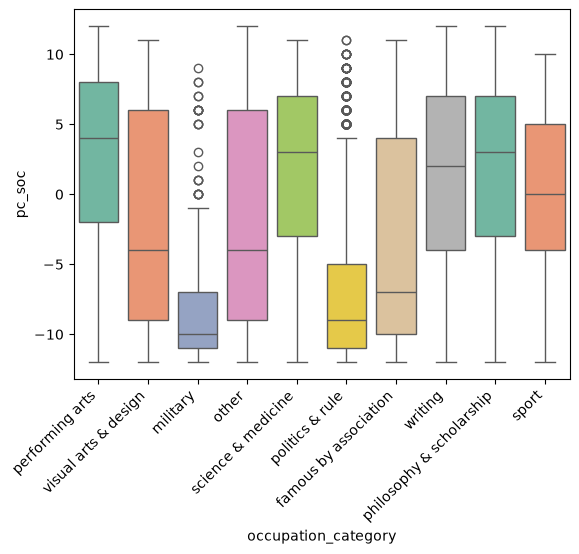

In [225]:
sns.boxplot(data=train, x='occupation_category', y='pc_soc', hue='occupation_category', palette='Set2', legend=False)
plt.xticks(rotation=45, ha='right') #roterer navnene på x aksen sånn at de ikke overlapper
plt.show()

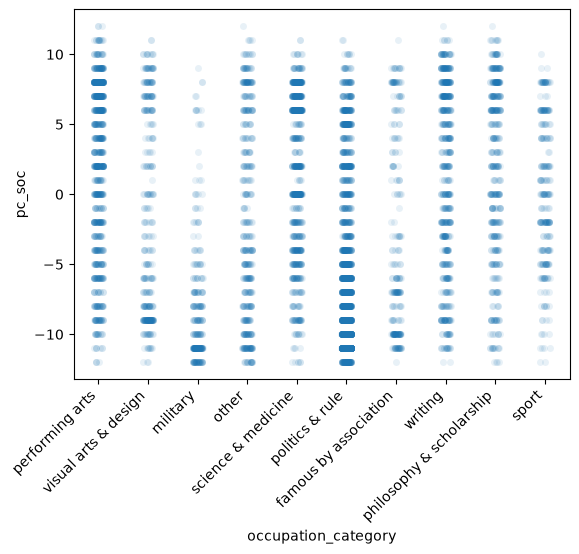

In [226]:
sns.stripplot(data=train, x='occupation_category', y='pc_soc', alpha=0.1, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

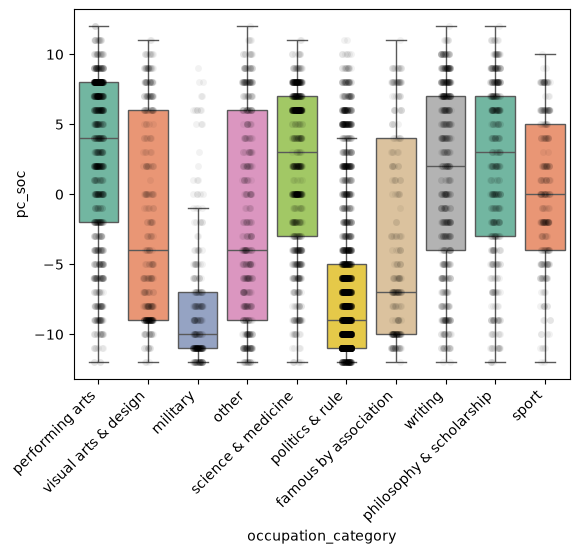

In [227]:
sns.boxplot(data=train, x='occupation_category', y='pc_soc', showfliers=False, hue='occupation_category', palette='Set2', legend=False)
sns.stripplot(data=train, x='occupation_category', y='pc_soc', color='black', alpha=0.05, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.show()

Her følger modellen også de samme stereotypene, military og politics og rule er mer autoritær, mens det er mer spredning i de andre kategoriene. Det er interesant at selv de kategoriene som lener seg mot liberal siden er ikke like tydelig som de som er klart autoritær, noe som kan tyde på at modellen enten er litt usikker eller lener seg selv litt mot autoritæritet.

## Favoritt dyr

In [228]:
# Renser teksten litt (små bokstaver, fjerner mellomrom, fjerner "the")
train['animal_clean'] = train['personal.favorite_animal'].str.strip().str.lower().str.replace(r'^the\s+', '', regex=True)

# Finner de mest populære dyrene 
top_animals = train['animal_clean'].value_counts().head(10).index

# Filtrerer til kun disse dyrene
animal_subset = train[train['animal_clean'].isin(top_animals)]

# Krysstabell: jobbtype x dyr
crosstab = pd.crosstab(animal_subset['occupation_category'], animal_subset['animal_clean'])

In [229]:
def top_words(series, n=20):
    words = re.findall(r'\w+', ' '.join(series.dropna()).lower())
    return Counter(words).most_common(n)

- Funkjson som finner de 20 mest populære ordene filtrert for favoritt dyr 

In [230]:
top_words(train['animal_clean'])

[('falcon', 1389),
 ('wolf', 1172),
 ('eagle', 762),
 ('horse', 637),
 ('lion', 590),
 ('swan', 308),
 ('owl', 254),
 ('greyhound', 157),
 ('tiger', 151),
 ('dog', 140),
 ('a', 135),
 ('crane', 121),
 ('raven', 112),
 ('grey', 90),
 ('elephant', 78),
 ('cat', 64),
 ('leopard', 58),
 ('bear', 52),
 ('dragon', 43),
 ('peacock', 43)]

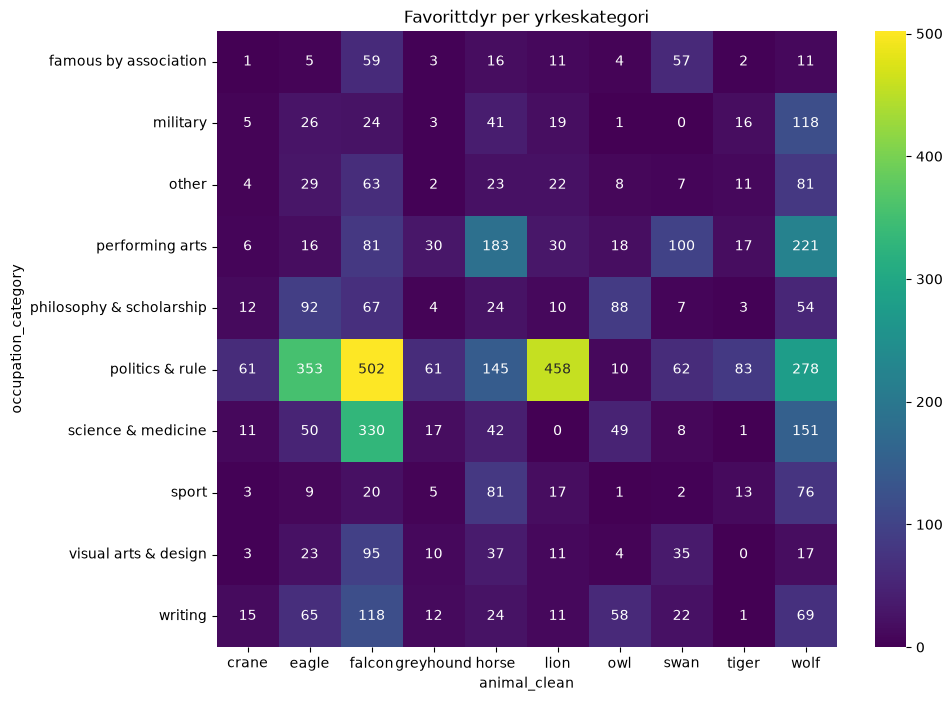

In [231]:
plt.figure(figsize=(10,8))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='viridis')
plt.title('Favorittdyr per yrkeskategori')
plt.show()

In [232]:
train['occupation_category'].value_counts().head(20)

occupation_category
politics & rule             2479
performing arts              980
science & medicine           837
writing                      608
philosophy & scholarship     453
other                        446
visual arts & design         350
military                     288
sport                        272
famous by association        261
Name: count, dtype: int64

- Det er en klar skjevhet i dataene til occupation_category som gjør at de top dyrene nesten alle kommer fra politcs og rule fordi de er klart flest i den kategorien

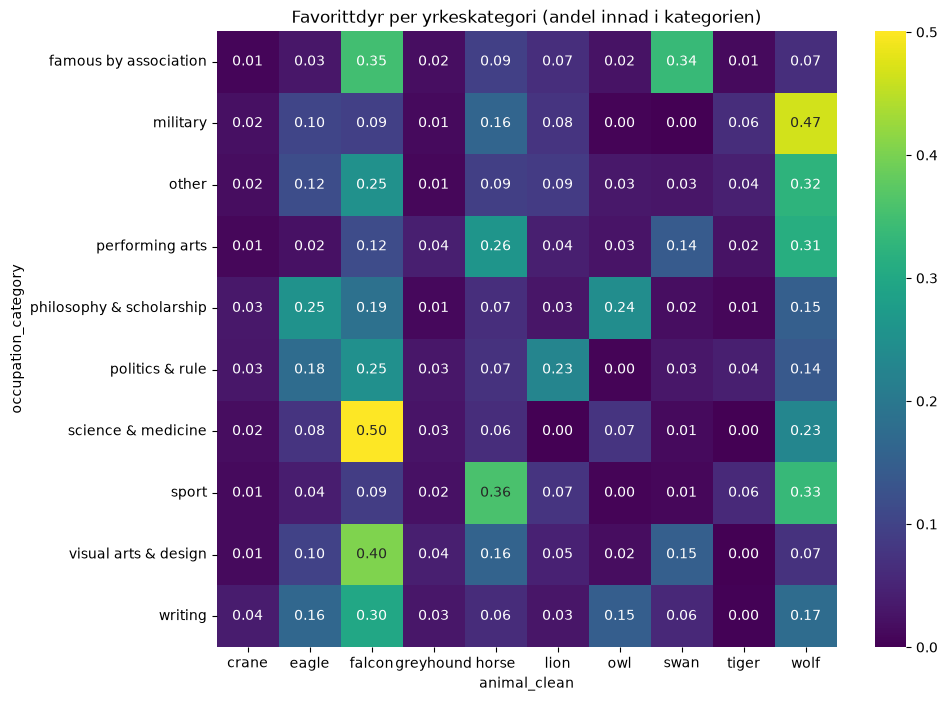

In [233]:
# Normaliserer per yrkeskategori (rad) sånn at hver rad summerer til 1
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0)

plt.figure(figsize=(10,8))
sns.heatmap(crosstab_pct, annot=True, fmt='.2f', cmap='viridis')
plt.title('Favorittdyr per yrkeskategori (andel innad i kategorien)')
plt.show()

I det normaliserte heatmapet så ser man mer tydelig at falcon er det mest valgte dyret. 50% i science og medicine noe som kanskje er en stereotyper modellen har om at science og medicine folk er fokuserte eller har et "falkesyn". Falcon er også størst andel i visual art og design, writing, other og politics and rule. Falcon som favorittdyr til politikere og ledere gir mening, det er et rovdyr eller har symbolikk som overlapper med måter ledere vil bli sett på. Det som jeg er litt mer usikker på er hvorfor den har valgt falcon som favorittdyr på writing og visual art og design. Jeg ser ingen åpenbare stereotyper her som gjør at jeg begynner å tenke om at falcon som favorittdyr er en bias eller en standard som modellen har siden det er så stor prosent av settet. Jeg føler at det er størst andel av other som har falcon som favorittdyr og det er også pekende på dette. Ellers føler jeg at de andre dyrene passer ganske bra til de forventede stereotypene. Philosophy og scolarship har både owl og eagle som gir mening. Wolf er spredt ganske jevnt utover med flest i military og sport, noe som jeg mener også gir mening utifra setrotyper

## Tidstrender

- Ser på år personene født utifra den politiske scoren

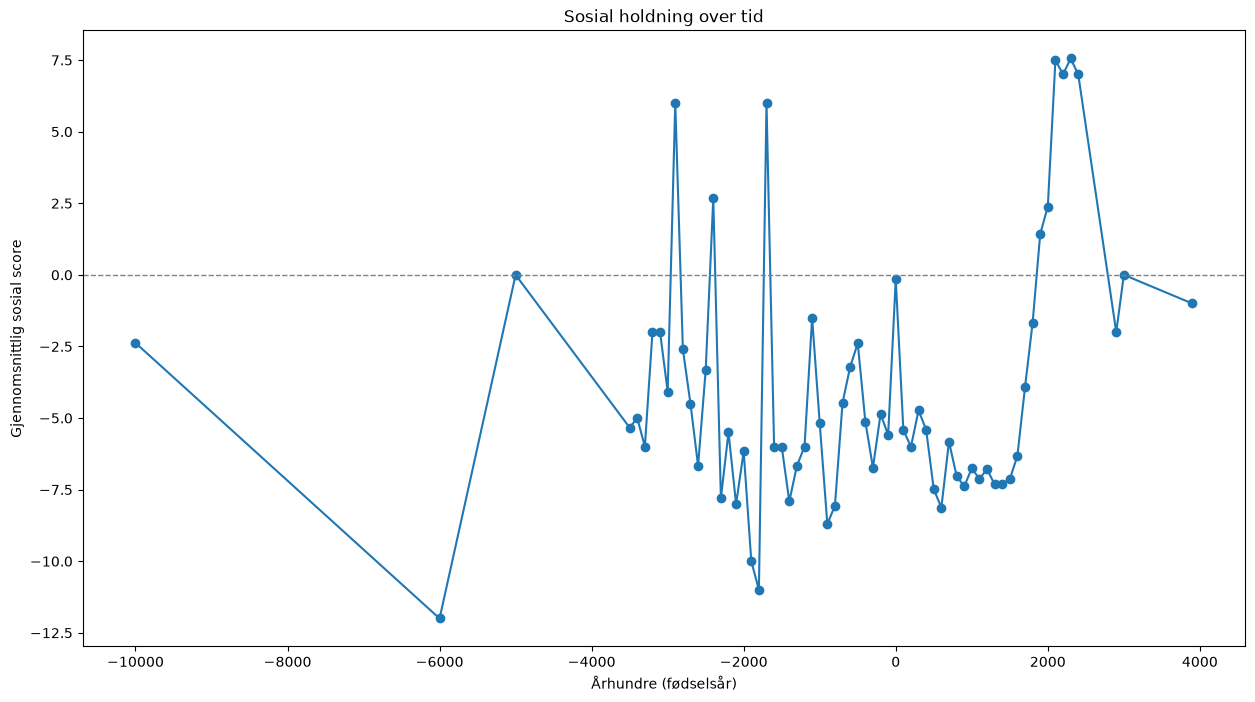

In [234]:
train['century'] = (train['born'] // 100) * 100

trend = train.groupby('century')['pc_soc'].mean()

trend.plot(marker='o', figsize=(15,8))
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Århundre (fødselsår)')
plt.ylabel('Gjennomsnittlig sosial score')
plt.title('Sosial holdning over tid')
plt.show()

Grafen viser at sosial holdning svinger kraftig gjennom historien, spesielt i de eldste periodene. Fra -10 000 til -2000 hopper kurven mye opp og ned, men jeg tror ikke dette er et reelt mønster. Det er sannsynligvis bare veldig få personer født i disse periodene, så gjennomsnittet blir styrt av en eller to enkeltpersoner.

Fra rundt -1500 til år 0 flater kurven mer ut, men ligger stabilt under null. Det gir mening. Modellen gir antikkens personer en mer autoritær holdning, som stemmer med at man ikke forventer at f.eks. en romer skal ha moderne liberale syn på ting som kjønn eller innvandring.

Det mest interessante funnet er det store skiftet som starter rundt år 1700 til 1800: kurven stiger jevnt fra autoritær til liberal og flater ut på et høyt platå rundt år 2000 til 2500. Dette tror jeg viser at modellen kobler sosial holdning direkte til fødselsår og projiserer moderne, liberale verdier på personer født nærmere vår tid. Altså en tydelig anakronisme, siden dette sier mer om hva modellen forventer av "noen født nylig" enn om personen faktisk hadde de holdningene.

Mot slutten (etter ca. 2500) faller kurven brått igjen. Dette er nok fiktive personer som modellen har anslått som mer autoritære enn nåtidens mennesker. Det kan også være at det er veldig få som er i det tidsrommet som gjør at gjennomsnittet blir veldig vektet på dem slik som de som er født i årene -2000 og nedover.


- Ser på årtusenet personene født utifra den politisk økonomiske scoren

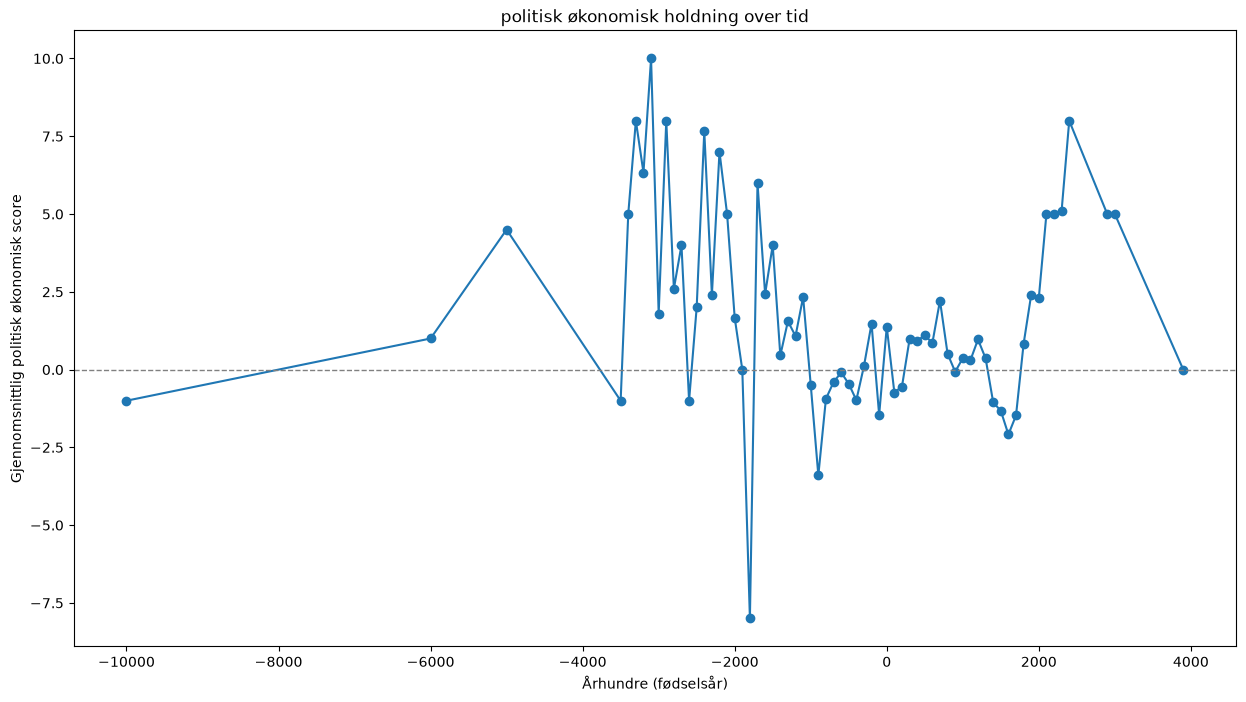

In [235]:
train['century'] = (train['born'] // 100) * 100

trend = train.groupby('century')['pc_econ'].mean()

trend.plot(marker='o', figsize=(15,8))
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Århundre (fødselsår)')
plt.ylabel('Gjennomsnittlig politisk økonomisk score')
plt.title('politisk økonomisk holdning over tid')
plt.show()

Grafen svinger mye gjennom hele tidslinjen, uten et like tydelig og jevnt skifte som vi så for sosial holdning. Fra -10 000 til -6000 ligger kurven nær null, men med veldig få personer bak hvert punkt er dette usikkert. Fra -3500 til -1500 er det store hopp opp og ned mellom -1 og 10, inkludert et kraftig bunnpunkt ned mot -8 rundt -1800. Dette tyder på lite data og enkeltpersoner som drar gjennomsnittet i ulike retninger, ikke et stabilt mønster.

Fra rundt -1000 og fram til år 0 flater kurven mer ut og ligger stort sett rundt 0, med noe variasjon mellom -1,5 og 1,5. Fra år 0 og utover er det en svak, ujevn stigning fram mot en topp rundt år 2500 (opp mot 8), før kurven faller tilbake mot 0 igjen nær år 4000.

Sammenlignet med sosial holdning er mønsteret her mye svakere og mindre konsistent. Det tyder på at modellen ikke kobler økonomisk holdning like sterkt til fødselsår som den gjør med sosial holdning. Det gir en viss mening: begreper som "venstre/høyre i økonomisk politikk" er mer knyttet til spesifikke politiske og økonomiske systemer som gjør at modellen har noe mer konkret å feste stereotypene og biasene sine på.


# DEL 2

- Oppgave A: regresjon, predikerer born
- Oppgave B: klassifikasjon, predikerer occupation_category
- Alt som skal læres fra data (median, skalering, one-hot og tekstordforråd), læres kun fra train og brukes så på val og test

In [236]:
from scipy.sparse import hstack

from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, balanced_accuracy_score, f1_score,
                             confusion_matrix, classification_report)

seed = 42

## Målvariabler

- Regresjon på born, jeg avgrenser intervallet til ca år -3500 og 2025 siden det er ca i disse intervallene det er flest ekte figurer, men fiktive figurer kan være hvor som helst. Jeg bergrenser den fordi jeg så i del 1 at det er så få  utenfor dette intervallet at det skaper outliers og dominert treningen. Begrensingen gjelder bare på regresjonsvaiablene jeg lager, selve train er uendret

- Klassifikasjon er på occupation_category
   

In [237]:
y_train_reg = train['born'].clip(-3500, 2025)
y_val_reg   = val['born'].clip(-3500, 2025)
y_test_reg  = test['born'].clip(-3500, 2025)

y_train_cls = train['occupation_category']
y_val_cls   = val['occupation_category']
y_test_cls  = test['occupation_category']

print('Andel clippede verdier i train:', (train['born'] != y_train_reg).mean().round(4))

Andel clippede verdier i train: 0.0057


Dette betyr at ca 0,57% hadde tall i born utenfor intervallet og er ikke tatt med

## Tall-features

- Bruker Big Five score og de politiske aksene fra del 1 som allerde ligger i train, val og test
- Samler kolonnene som skal logges i en liste
- Samler tall kolonner i en liste



In [238]:
log_kol = ['values.random_people_per_me'] + [col for col in train.columns if col.startswith('moral_exchange_rates.')]

tall_kol = (['EXT_score', 'EST_score', 'AGR_score', 'CSN_score', 'OPN_score', 'pc_econ', 'pc_soc']
            + log_kol
            + ['values.dictator_give_pct', 'values.p_god_exists', 'values.p_living_in_simulation',
               'values.wants_to_live_forever', 'personal.self_described_iq', 'personal.height_cm',
               'personal.weight_kg', 'personal.life_satisfaction', 'bmi'])

- Funksjonen lag_tall:
    - Gjør om "wants_to_live_forever" til 1 eller 0 istedenfor True eller False
    - "random_people_near_me og "moral_exchange_rates" logges og begrenses til 1e-12
    - høyde og vekt klippes, høyde klippes i intervallet, 30 til 300 cm og vekt klippes til intervallet 2 til 500 kg
    - Regner ut BMI (vekt) / (((kilo) / 100) ** 2) og begrenser den til intervallet 5, 60

In [239]:
def lag_tall(d):
    d = d.copy()

    d['values.wants_to_live_forever'] = d['values.wants_to_live_forever'].astype(float)

    for col in log_kol:
        d[col] = np.log10(d[col].clip(lower=1e-12))

    d['personal.height_cm'] = d['personal.height_cm'].clip(30, 300)
    d['personal.weight_kg'] = d['personal.weight_kg'].clip(2, 500)
    d['bmi'] = (d['personal.weight_kg'] / (d['personal.height_cm'] / 100) ** 2).clip(5, 60)

    return d[tall_kol]

tall_train = lag_tall(train)
tall_val   = lag_tall(val)
tall_test  = lag_tall(test)

- Manglende verdier fylles med medianen fra train (det mangler bare rundt 15 rader per kolonne)
- Skalerer med StandardScaler som læres på train

In [240]:
median = tall_train.median()
tall_train = tall_train.fillna(median)
tall_val   = tall_val.fillna(median)
tall_test  = tall_test.fillna(median)

scaler = StandardScaler()
tall_train = scaler.fit_transform(tall_train)
tall_val   = scaler.transform(tall_val)
tall_test  = scaler.transform(tall_test)

# Kategoriske features

- Samler kategoriske kolonner i en liste
- One-hot med get_dummies
- Val og test tvinges til samme kolonner som train med reindex, sånn at kategorier som bare finnes i val/test ikke lager nye kolonner 

In [241]:
kat_kol = ['values.friend_crime_testify', 'values.child_quality_most_important', 'values.free_will',
           'personal.favorite_color', 'personal.favorite_season', 'personal.legacy_or_happiness']

kat_train = pd.get_dummies(train[kat_kol].fillna('missing')).astype(float)
kat_val   = pd.get_dummies(val[kat_kol].fillna('missing')).astype(float).reindex(columns=kat_train.columns, fill_value=0)
kat_test  = pd.get_dummies(test[kat_kol].fillna('missing')).astype(float).reindex(columns=kat_train.columns, fill_value=0)

print(kat_train.shape)

(6974, 36)


# Tekst features

- Samler alle tekstkolonnene i en liste
- TF-IDF, term frequency - inverse document frequency på hvert av tekstfeltene, både på ord og toordssekvenser, lært på train
- Hvert felt får sin egen TF-IDF, sånn at falcon som dyr ikke blandes med falcon som boktittel
- min_df=3 fjerner ord som bare forekommer i mindre enn 3 personer sitt svar

In [242]:
tekst_kol = ['personal.favorite_person', 'personal.favorite_book', 'personal.favorite_painting',
             'personal.favorite_animal', 'personal.last_meal',
             'personal.favorite_thing_about_bergen', 'personal.favorite_data_science_fact']

tekst_deler_train, tekst_deler_val, tekst_deler_test = [], [], []

for col in tekst_kol:
    tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=True, max_features=2000)
    tekst_deler_train.append(tfidf.fit_transform(train[col].fillna('')))
    tekst_deler_val.append(tfidf.transform(val[col].fillna('')))
    tekst_deler_test.append(tfidf.transform(test[col].fillna('')))

tekst_train = hstack(tekst_deler_train).tocsr()
tekst_val   = hstack(tekst_deler_val).tocsr()
tekst_test  = hstack(tekst_deler_test).tocsr()

print(tekst_train.shape)

(6974, 9082)


# Setter sammen feature matrisene

- X_uten_tekst er tall + kategorier uten tekst
- X_med_tekst er tall + kategorier + tekst. Brukes til lineære modeller, som tar sparse matriser
- X_svd er tall + kategorier + tekst komprimert til 100 komponenter med TruncatedSVD (tekst_svd). Brukes til HistGradientBoosting, som trenger en tett matrise


In [243]:
X_uten_tekst_train = np.hstack([tall_train, kat_train.values])
X_uten_tekst_val   = np.hstack([tall_val, kat_val.values])
X_uten_tekst_test  = np.hstack([tall_test, kat_test.values])

X_med_tekst_train = hstack([X_uten_tekst_train, tekst_train]).tocsr()
X_med_tekst_val   = hstack([X_uten_tekst_val, tekst_val]).tocsr()
X_med_tekst_test  = hstack([X_uten_tekst_test, tekst_test]).tocsr()

svd = TruncatedSVD(100, random_state=seed)
tekst_svd_train = svd.fit_transform(tekst_train)
tekst_svd_val   = svd.transform(tekst_val)
tekst_svd_test  = svd.transform(tekst_test)

X_svd_train = np.hstack([X_uten_tekst_train, tekst_svd_train])
X_svd_val   = np.hstack([X_uten_tekst_val, tekst_svd_val])
X_svd_test  = np.hstack([X_uten_tekst_test, tekst_svd_test])

print(X_uten_tekst_train.shape, X_med_tekst_train.shape, X_svd_train.shape)

(6974, 61) (6974, 9143) (6974, 161)


# Ytelsesmål

- Regresjon: MAE (Mean absolute error) som hovedmål. RMSE (Root mean square deviation) og R^2 som støttemål
- Klassifikasjon: macro-F1 som hovedmål. Balanced accuracy og accuracy som støttemål

In [244]:
def mål_reg(y_sann, pred):
    return {'MAE': mean_absolute_error(y_sann, pred),
            'RMSE': mean_squared_error(y_sann, pred) ** 0.5,
            'R2': r2_score(y_sann, pred)}

def mål_cls(y_sann, pred):
    return {'macro_F1': f1_score(y_sann, pred, average='macro'),
            'bal_acc': balanced_accuracy_score(y_sann, pred),
            'accuracy': accuracy_score(y_sann, pred)}

res_reg = {}
res_cls = {}

# Oppgave A: regresjon 

- Lager en dummy som alltid predikerer medianen av born i treningsdata som en baseline

In [245]:
dummy_reg = DummyRegressor(strategy='median')
dummy_reg.fit(X_uten_tekst_train, y_train_reg)
res_reg['Dummy (median)'] = mål_reg(y_val_reg, dummy_reg.predict(X_uten_tekst_val))

pd.DataFrame(res_reg).T.round(3)

,MAE,RMSE,R2
Dummy (median),465.143,937.812,-0.224


# Lineær regresjon uten tekst og med tekst

- På regresjonen uten tekst brukes X_uten_tekst 
- På regresjonen med tekst brukes X_svd, dette komprimerer tekstfletene til 100 kompontenter. 
- Å sammenligne med og uten tekst viser hvor mye tekstfeltene bidrar

In [246]:
linreg_uten = LinearRegression().fit(X_uten_tekst_train, y_train_reg)
res_reg['LinReg (uten tekst)'] = mål_reg(y_val_reg, linreg_uten.predict(X_uten_tekst_val))

linreg_med = LinearRegression().fit(X_svd_train, y_train_reg)
res_reg['LinReg (med tekst)'] = mål_reg(y_val_reg, linreg_med.predict(X_svd_val))

pd.DataFrame(res_reg).T.round(3).sort_values('MAE')

,MAE,RMSE,R2
LinReg (med tekst),369.359,577.344,0.536
LinReg (uten tekst),462.842,726.025,0.266
Dummy (median),465.143,937.812,-0.224


# HistGradientBoosting

- Bruker absolute_error som tap, siden MAE er ytelsesmålet
- Early stopping = True stopper treningen når modellen slutter å bli bedre

In [247]:
hgb_reg = HistGradientBoostingRegressor(loss='absolute_error', learning_rate=0.05, max_iter=300,
                                        early_stopping=True, random_state=seed)
hgb_reg.fit(X_svd_train, y_train_reg)
res_reg['HistGB (med tekst)'] = mål_reg(y_val_reg, hgb_reg.predict(X_svd_val))

pd.DataFrame(res_reg).T.round(3).sort_values('MAE')

,MAE,RMSE,R2
HistGB (med tekst),281.194,628.887,0.450
LinReg (med tekst),369.359,577.344,0.536
LinReg (uten tekst),462.842,726.025,0.266
Dummy (median),465.143,937.812,-0.224


- HistGB bommer i snitt med 281 år (MAE), mot 465 år for dummy som alltid gjetter medianen
- Lineær regresjon uten tekst bommer med 463 år, nesten like mye som dummy. Tall og kategorier alene sier altså nesten ingenting om fødselsår
- Lineær regresjon med tekst bommer med 369 år. Tekstsvarene er det som gir mest informasjon
- HistGB har lavest MAE, men lineær regresjon har lavest RMSE (577 mot 629) og høyest R² (0,54 mot 0,45). RMSE straffer store feil hardt, så det tyder på at HistGB treffer bedre for de fleste, men bommer veldig for noen få

# Feilanalyse for regresjon

- Ser på feilen for ekte og fiktive personer hver for seg, og per tidsperiode

In [248]:
feil = pd.DataFrame()
feil['sann'] = y_val_reg.values
feil['pred'] = hgb_reg.predict(X_svd_val)
feil['type'] = val['type'].values
feil['abs_feil'] = (feil['sann'] - feil['pred']).abs()

# deler inn i tidsperioder
grenser = [-4000, 0, 1000, 1500, 1800, 1900, 2100]
navn = ['<0', '0-1000', '1000-1500', '1500-1800', '1800-1900', '>=1900']
feil['periode'] = pd.cut(feil['sann'], bins=grenser, labels=navn)

print(feil.groupby('type')['abs_feil'].agg(['mean', 'count']).round(1))
print(feil.groupby('periode')['abs_feil'].agg(['mean', 'count']).round(1))

            mean  count
type                   
fictional  912.7    132
real       220.0   1363
             mean  count
periode                 
<0         1486.5    145
0-1000      555.8    113
1000-1500   230.8    161
1500-1800   157.7    208
1800-1900   100.6    334
>=1900       72.0    534


- Fiksjonelle personer får en predikert feil på ca 912 år som er mye større enn 220 som de ekte personene får predikert
- Ser også at feilen for predikert år blir bedre og bedre jo med moderne det blir. Det starter med en feil på ca 1500 år når personen er førdt før år 0 og ender på en feil på 72 år etter år 1900
- Visualiserer dette med grafene under 

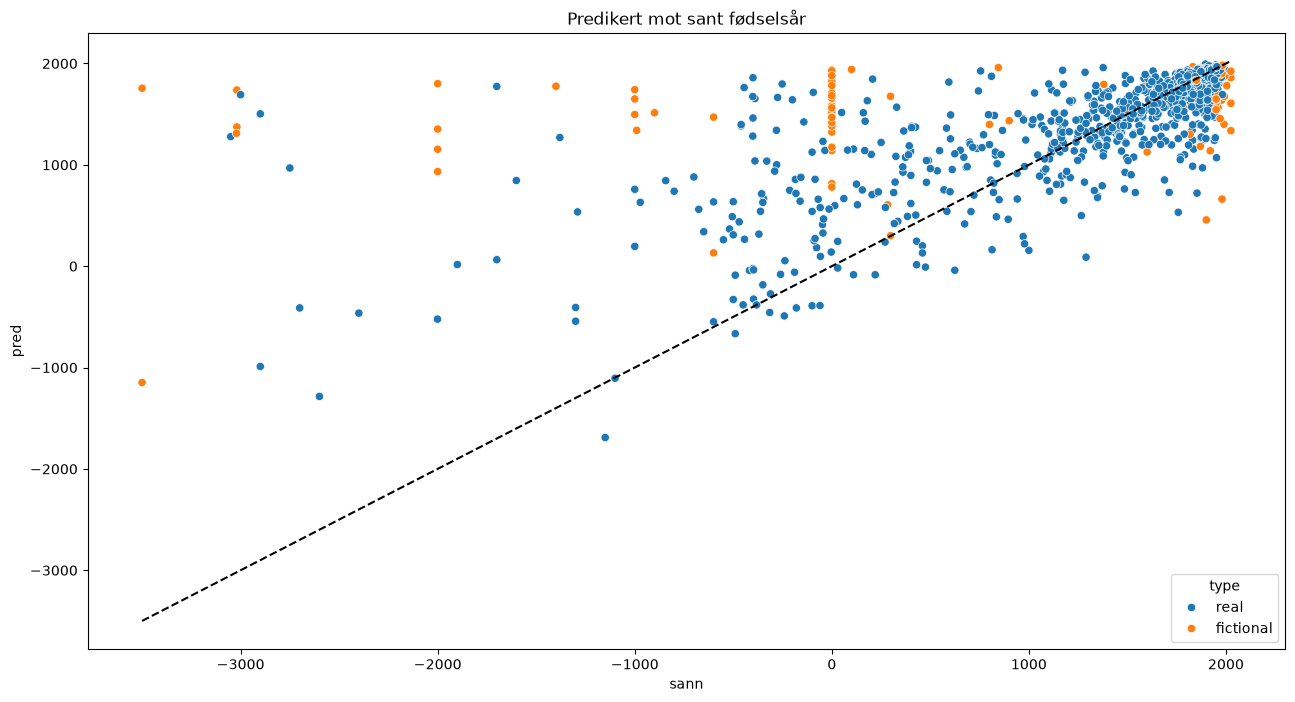

In [249]:
plt.figure(figsize=(34, 8))

plt.subplot(1, 2, 1)
sns.scatterplot(data=feil, x='sann', y='pred', hue='type', alpha=1)
plt.plot([-3500, 2025], [-3500, 2025], 'k--')
plt.title('Predikert mot sant fødselsår')
plt.show()

Text(0, 0.5, 'Feil i år')

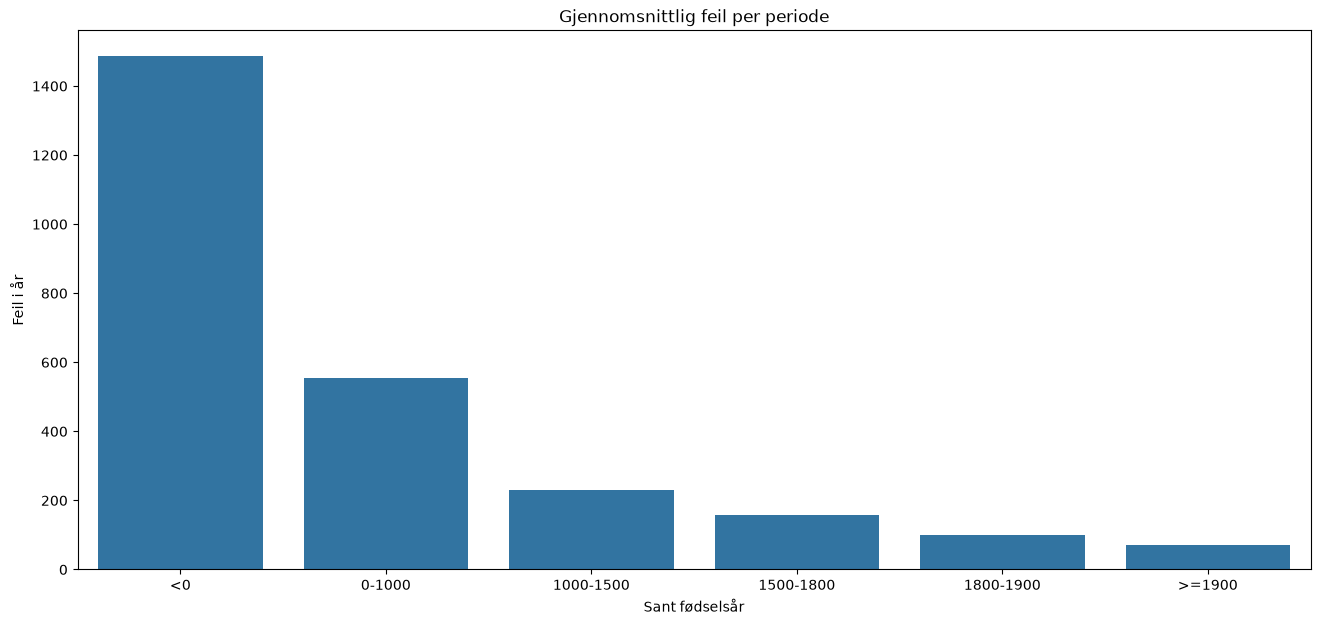

In [250]:
plt.figure(figsize=(35, 7))

plt.subplot(1, 2, 1)
sns.barplot(data=feil, x='periode', y='abs_feil', errorbar=None)
plt.title('Gjennomsnittlig feil per periode')
plt.xlabel('Sant fødselsår')
plt.ylabel('Feil i år')


# Oppgave B: Klassifikasjon av occupation_category

- Dummy som alltid predikerer den vanligste klassen (politics & rule) som en baseline

In [251]:
dummy_cls = DummyClassifier(strategy='most_frequent')
dummy_cls.fit(X_uten_tekst_train, y_train_cls)
res_cls['Dummy (største klasse)'] = mål_cls(y_val_cls, dummy_cls.predict(X_uten_tekst_val))

pd.DataFrame(res_cls).T.round(3)

,macro_F1,bal_acc,accuracy
Dummy (største klasse),0.052,0.1,0.355


# Logistisk regresjon med og uten tekst

- class_weight = 'balanced' vekter små klasser opp, siden klassene er ubalanserte
- Prøver flere verdier av C og velger den med høyest macro-F1 på valideringsdata

In [252]:
for C in [0.1, 1, 10]:
    logreg = LogisticRegression(C=C, max_iter=2000, class_weight='balanced').fit(X_uten_tekst_train, y_train_cls)
    print('uten tekst, C', C, ':', round(mål_cls(y_val_cls, logreg.predict(X_uten_tekst_val))['macro_F1'], 3))

for C in [0.3, 1, 3, 10]:
    logreg = LogisticRegression(C=C, max_iter=2000, class_weight='balanced').fit(X_med_tekst_train, y_train_cls)
    print('med tekst, C', C, ':', round(mål_cls(y_val_cls, logreg.predict(X_med_tekst_val))['macro_F1'], 3))

uten tekst, C 0.1 : 0.521
uten tekst, C 1 : 0.521
uten tekst, C 10 : 0.524
med tekst, C 0.3 : 0.695
med tekst, C 1 : 0.708
med tekst, C 3 : 0.7
med tekst, C 10 : 0.698


Velger C = 10 for uten tekst og C = 1 for med tekst

In [253]:
lr_uten = LogisticRegression(C=10, max_iter=2000, class_weight='balanced').fit(X_uten_tekst_train, y_train_cls)
res_cls['LogReg (uten tekst)'] = mål_cls(y_val_cls, lr_uten.predict(X_uten_tekst_val))

lr_med = LogisticRegression(C=1, max_iter=2000, class_weight='balanced').fit(X_med_tekst_train, y_train_cls)
res_cls['LogReg (med tekst)'] = mål_cls(y_val_cls, lr_med.predict(X_med_tekst_val))

pd.DataFrame(res_cls).T.round(3).sort_values('macro_F1', ascending=False)

,macro_F1,bal_acc,accuracy
LogReg (med tekst),0.708,0.725,0.766
LogReg (uten tekst),0.524,0.575,0.597
Dummy (største klasse),0.052,0.100,0.355


# HistGradientBoosting

In [254]:
hgb_cls = HistGradientBoostingClassifier(learning_rate=0.08, max_iter=200, class_weight='balanced',
                                         early_stopping=True, random_state=seed)
hgb_cls.fit(X_svd_train, y_train_cls)
res_cls['HistGB (med tekst)'] = mål_cls(y_val_cls, hgb_cls.predict(X_svd_val))

pd.DataFrame(res_cls).T.round(3).sort_values('macro_F1', ascending=False)

,macro_F1,bal_acc,accuracy
LogReg (med tekst),0.708,0.725,0.766
HistGB (med tekst),0.665,0.652,0.743
LogReg (uten tekst),0.524,0.575,0.597
Dummy (største klasse),0.052,0.100,0.355


- Logistisk regresjon med tekst er best (macro-F1 ca. 0,71), foran HistGB (ca. 0,66). Uten tekst faller den til ca. 0,52. Dummy ligger på ca. 0,05
- Tekstfeltene gir altså mest signal også for yrkeskategori

# Feilanalyse for Klassifikasjon



- Klassifikasjonsrapport per klasse og confusion matrix, normalisert per sann klasse
- Sjekker også ekte mot fiktive personer

In [255]:
pred_cls = lr_med.predict(X_med_tekst_val)
print(classification_report(y_val_cls, pred_cls, zero_division=0))

                          precision    recall  f1-score   support

   famous by association       0.39      0.55      0.46        56
                military       0.68      0.81      0.74        62
                   other       0.54      0.57      0.56        96
         performing arts       0.79      0.77      0.78       210
philosophy & scholarship       0.57      0.68      0.62        97
         politics & rule       0.91      0.83      0.87       531
      science & medicine       0.88      0.87      0.88       179
                   sport       0.84      0.69      0.76        59
    visual arts & design       0.71      0.84      0.77        75
                 writing       0.67      0.64      0.65       130

                accuracy                           0.77      1495
               macro avg       0.70      0.73      0.71      1495
            weighted avg       0.78      0.77      0.77      1495



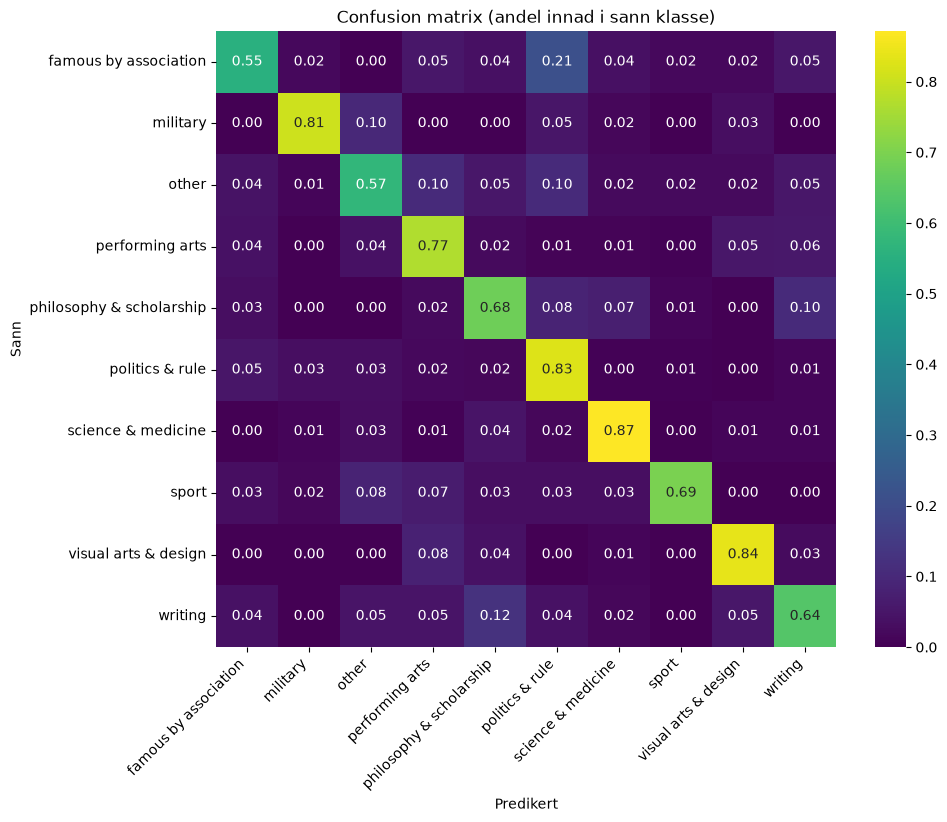

In [256]:
klasser = sorted(y_train_cls.unique())
konfusjon = confusion_matrix(y_val_cls, pred_cls, labels=klasser, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(konfusjon, annot=True, fmt='.2f', cmap='viridis', xticklabels=klasser, yticklabels=klasser)
plt.xlabel('Predikert')
plt.ylabel('Sann')
plt.title('Confusion matrix (andel innad i sann klasse)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [257]:
for personer in ['real', 'fictional']:
    maske = (val['type'] == personer).values
    print(personer, 'macro-F1:', round(f1_score(y_val_cls[maske], pred_cls[maske], average='macro'), 3), '| n =', maske.sum())

real macro-F1: 0.735 | n = 1363
fictional macro-F1: 0.337 | n = 132


- Science & medicine og politics & rule er lettest å klassifisere (F1 ca. 0,88 og 0,87). Famous by association (ca. 0,46) og other (ca. 0,56) er vanskeligst
- Fiktive figurer er mye vanskeligere (macro-F1 ca. 0,34) enn ekte personer (ca. 0,73)

# Endelig test

- Testdata skal bare brukes én gang, til slutt, på modellene som ble valgt på valideringsdata

In [259]:
print('Regresjon (HistGB):', {navn: round(verdi, 3) for navn, verdi in mål_reg(y_test_reg, hgb_reg.predict(X_svd_test)).items()})
print('Klassifikasjon (LogReg med tekst):', {navn: round(verdi, 3) for navn, verdi in mål_cls(y_test_cls, lr_med.predict(X_med_tekst_test)).items()})

Regresjon (HistGB): {'MAE': 270.548, 'RMSE': 565.848, 'R2': 0.527}
Klassifikasjon (LogReg med tekst): {'macro_F1': 0.697, 'bal_acc': 0.722, 'accuracy': 0.761}
